# Trabajo Práctico Integrador — Data Analytics
### Alumno:
Alejandro Matesa

### Comisión:
C26106

## Datasets utilizados

- ventas.csv
- clientes.csv
- marketing.csv

# Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np

# Carga de Datasets

Los datasets son cargados desde enlaces públicos de Google Drive para garantizar la reproducibilidad del proyecto y permitir su correcta ejecución desde cualquier entorno.

In [ ]:
def cargar_dataset(link):

    # Extraer ID del archivo
    file_id = link.split('/d/')[1].split('/')[0]

    # Generar URL de descarga
    url = f'https://drive.google.com/uc?id={file_id}'

    # Leer archivo CSV
    df = pd.read_csv(url)

    return df

In [ ]:
# Links públicos de los datasets

link_ventas = 'https://drive.google.com/file/d/1AeB7wVLe497ll3Uwjl4CFkTclzLQTC2U/view?usp=sharing'
link_clientes = 'https://drive.google.com/file/d/1UZReEcqzvZxTojNexzj6G5eTqEKqeJpQ/view?usp=sharing'
link_marketing = 'https://drive.google.com/file/d/1aifz9UTt0kskzB4RzcOrUo2xQGXHzuDp/view?usp=sharing'

# Carga de DataFrames

ventas = cargar_dataset(link_ventas)
clientes = cargar_dataset(link_clientes)
marketing = cargar_dataset(link_marketing)

# Validación de Carga de Datos

In [ ]:
print("Ventas")
display(ventas.head())

print("Clientes")
display(clientes.head())

print("Marketing")
display(marketing.head())

Ventas


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


Clientes


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


Marketing


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


# Etapa 1 — Recopilación y Preparación de Datos

## Análisis Exploratorio Inicial

En esta etapa se realiza una exploración inicial de los conjuntos de datos con el objetivo de comprender su estructura, identificar tipos de variables, detectar posibles problemas de calidad y obtener una visión general de la información disponible.

El análisis exploratorio permite:

- conocer la composición de los datasets,
- identificar valores faltantes o inconsistentes,
- detectar registros duplicados,
- comprender relaciones entre variables,
- y preparar los datos para etapas posteriores de limpieza y transformación.

## 1_2 - Cálculo de Ventas Mensuales

En esta sección se realiza un cálculo de ventas utilizando variables y operadores matemáticos aplicados al dataset de ventas.

Para ello se calcula el ingreso generado por cada venta a partir del precio y la cantidad vendida, y posteriormente se obtiene el total acumulado de ventas.

In [ ]:
# Visualizamos registros iniciales
ventas.head(2)

# Variables del cálculo

precio = 150
cantidad = 3

# Cálculo básico
venta_total = precio * cantidad

print(f"Venta total calculada: ${venta_total}")

Venta total calculada: $450


In [ ]:
# Cálculo aplicado al dataset real

ventas["venta_total"] = (
    ventas["precio"]
    .str.replace("$", "", regex=False)
    .astype(float)
    * ventas["cantidad"]
)

ventas[["producto", "precio", "cantidad", "venta_total"]].head()

,producto,precio,cantidad,venta_total
0,Cuadro decorativo,$69.94,5.0,349.70
1,Lámpara de mesa,$105.10,5.0,525.50
2,Secadora,$97.96,3.0,293.88
3,Heladera,$114.35,8.0,914.80
4,Secadora,$106.21,4.0,424.84


In [ ]:
# Calculamos el total general de ventas

ventas_mensuales = ventas["venta_total"].sum()

print(f"Total de ventas registradas: ${ventas_mensuales:,.2f}")

Total de ventas registradas: $1,483,042.93


## 1_3 - Uso de Estructuras de Datos

Para representar los datos de ventas se utilizaron diccionarios dentro de una lista.

Se decidió utilizar diccionarios debido a que permiten almacenar información mediante pares clave-valor, facilitando la identificación de atributos como producto, precio y cantidad.

Además, el uso de listas permite almacenar múltiples registros de ventas de manera organizada.

Se utilizó el método `head()` para trabajar únicamente con una muestra reducida del dataset.

Esta decisión permite visualizar y validar la estructura de datos de manera más clara y eficiente, evitando procesar o mostrar la totalidad de los registros del conjunto de datos.


In [ ]:
# Crear lista para almacenar ventas

ventas_estructura = []

# Tomamos una muestra del dataset

for _, fila in ventas.head(5).iterrows():

    venta = {
        "id_venta": fila["id_venta"],
        "producto": fila["producto"],
        "precio": fila["precio"],
        "cantidad": fila["cantidad"]
    }

    ventas_estructura.append(venta)

# Mostrar estructura

ventas_estructura

[{'id_venta': 792,
  'producto': 'Cuadro decorativo',
  'precio': '$69.94',
  'cantidad': 5.0},
 {'id_venta': 811,
  'producto': 'Lámpara de mesa',
  'precio': '$105.10',
  'cantidad': 5.0},
 {'id_venta': 1156,
  'producto': 'Secadora',
  'precio': '$97.96',
  'cantidad': 3.0},
 {'id_venta': 1372,
  'producto': 'Heladera',
  'precio': '$114.35',
  'cantidad': 8.0},
 {'id_venta': 1546,
  'producto': 'Secadora',
  'precio': '$106.21',
  'cantidad': 4.0}]

## 1_4 - Análisis Exploratorio Inicial de los DataFrames

Se realiza un análisis exploratorio inicial (EDA) sobre cada conjunto de datos con el objetivo de comprender su estructura, tipos de variables, posibles inconsistencias y estado general de calidad.

Este proceso permite detectar problemas iniciales antes de avanzar hacia etapas de limpieza y transformación de datos.

In [ ]:
def resumen_eda(df):

    print("📊 Dimensiones del dataset")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    print("-" * 40)

    print("\n🔎 Tipos de datos")
    print(df.dtypes)
    print("-" * 40)

    print("\n🔎 Primeros registros")
    display(df.head(2))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    display(df.describe(include='all'))

    print("-" * 40)

    print("\n⚠️ Valores nulos por columna")
    nulos = df.isnull().sum()

    if (nulos > 0).any():
        print(nulos[nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos")

    print("-" * 40)

    print("\n🔁 Registros duplicados")
    duplicados = df.duplicated().sum()

    print(f"Cantidad de duplicados: {duplicados}")

    print("-" * 40)

## 1_5 - Calidad de Datos

En esta sección se aplica el análisis exploratorio inicial a cada dataset para identificar valores nulos, registros duplicados y posibles inconsistencias en los datos.

### EDA — Dataset Clientes

In [ ]:
resumen_eda(clientes)

📊 Dimensiones del dataset
Filas: 567
Columnas: 5
----------------------------------------

🔎 Tipos de datos
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object
----------------------------------------

🔎 Primeros registros


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04


----------------------------------------

📈 Estadísticas descriptivas


,id_cliente,nombre,edad,ciudad,ingresos
count,567.000000,567,567.000000,567,567.000000
unique,NaN,567,NaN,12,NaN
top,NaN,Micah Matis,NaN,Mar del Plata,NaN
freq,NaN,1,NaN,63,NaN
mean,284.000000,NaN,37.940035,NaN,34668.739012
std,163.823075,NaN,10.202885,NaN,12974.531446
min,1.000000,NaN,20.000000,NaN,170.290000
25%,142.500000,NaN,30.000000,NaN,26015.240000
50%,284.000000,NaN,37.000000,NaN,35066.830000
75%,425.500000,NaN,43.000000,NaN,42457.100000


----------------------------------------

⚠️ Valores nulos por columna
No hay valores nulos
----------------------------------------

🔁 Registros duplicados
Cantidad de duplicados: 0
----------------------------------------


### Hallazgos — Dataset Clientes

A partir del análisis exploratorio del dataset de clientes se identificó que el conjunto de datos contiene 567 registros y 5 variables asociadas a información demográfica y económica de los clientes.

No se detectaron valores nulos ni registros duplicados, lo que indica un buen nivel inicial de calidad de datos.

Las variables numéricas presentan formatos correctos (`int64` y `float64`), mientras que las variables categóricas como nombre y ciudad fueron interpretadas correctamente como tipo `object`.

En relación con la distribución de datos:

- La edad promedio de los clientes es de aproximadamente 38 años.
- Los ingresos presentan una media cercana a 34.669.
- Se identificó una amplia variabilidad en los ingresos, evidenciada por una desviación estándar elevada.
- La ciudad con mayor frecuencia de registros es Mar del Plata.

En términos generales, el dataset de clientes no requiere procesos importantes de limpieza inicial y se encuentra en condiciones adecuadas para análisis posteriores.

### EDA — Dataset Ventas

In [ ]:
resumen_eda(ventas)

📊 Dimensiones del dataset
Filas: 3035
Columnas: 7
----------------------------------------

🔎 Tipos de datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
venta_total    float64
dtype: object
----------------------------------------

🔎 Primeros registros


,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_total
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración,349.7
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración,525.5


----------------------------------------

📈 Estadísticas descriptivas


,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_total
count,3035.000000,3035,3033,3033.000000,3035,3035,3033.000000
unique,NaN,30,2590,NaN,364,3,NaN
top,NaN,Lámpara de mesa,$76.32,NaN,06/04/2024,Decoración,NaN
freq,NaN,181,5,NaN,24,1015,NaN
mean,1499.851400,NaN,NaN,6.496538,NaN,NaN,488.968985
std,866.465379,NaN,NaN,3.457250,NaN,NaN,334.594511
min,1.000000,NaN,NaN,1.000000,NaN,NaN,26.300000
25%,748.500000,NaN,NaN,3.000000,NaN,NaN,220.500000
50%,1502.000000,NaN,NaN,7.000000,NaN,NaN,418.050000
75%,2249.500000,NaN,NaN,9.000000,NaN,NaN,708.890000


----------------------------------------

⚠️ Valores nulos por columna
precio         2
cantidad       2
venta_total    2
dtype: int64
----------------------------------------

🔁 Registros duplicados
Cantidad de duplicados: 35
----------------------------------------


### Hallazgos — Dataset Ventas

El dataset de ventas contiene 3035 registros y 7 variables relacionadas con productos, cantidades vendidas, fechas y categorías comerciales.

Durante el análisis exploratorio se identificaron algunos problemas de calidad de datos que requerirán tratamiento en etapas posteriores.

Principales hallazgos detectados:

- La columna `precio` fue interpretada como tipo `object`, debido a la presencia del símbolo `$`.
- La columna `fecha_venta` también fue interpretada como `object`, por lo que será necesario convertirla a formato fecha (`datetime`).
- Se detectaron valores nulos en las columnas:
  - `precio`
  - `cantidad`
  - `venta_total`

En total se identificaron:

- 2 registros con valores faltantes en precio.
- 2 registros con valores faltantes en cantidad.
- 35 registros duplicados.

Además:

- El dataset contiene 30 productos distintos.
- La categoría más frecuente es "Decoración".
- La cantidad promedio vendida por operación es cercana a 6 unidades.

Debido a estos hallazgos, será necesario realizar procesos de limpieza y transformación de datos durante la siguiente etapa del proyecto.

### EDA — Dataset Marketing

In [ ]:
resumen_eda(marketing)

📊 Dimensiones del dataset
Filas: 90
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------

🔎 Primeros registros


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024


----------------------------------------

📈 Estadísticas descriptivas


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
count,90.000000,90,90,90.000000,90,90
unique,NaN,30,3,NaN,78,78
top,NaN,Adorno de pared,TV,NaN,25/09/2024,05/05/2024
freq,NaN,3,30,NaN,2,3
mean,45.500000,NaN,NaN,4.928667,NaN,NaN
std,26.124701,NaN,NaN,0.947750,NaN,NaN
min,1.000000,NaN,NaN,2.950000,NaN,NaN
25%,23.250000,NaN,NaN,4.372500,NaN,NaN
50%,45.500000,NaN,NaN,4.900000,NaN,NaN
75%,67.750000,NaN,NaN,5.562500,NaN,NaN


----------------------------------------

⚠️ Valores nulos por columna
No hay valores nulos
----------------------------------------

🔁 Registros duplicados
Cantidad de duplicados: 0
----------------------------------------


### Hallazgos — Dataset Marketing

El dataset de marketing contiene 90 registros y 6 variables relacionadas con campañas publicitarias, canales de difusión y costos asociados.

No se detectaron valores nulos ni registros duplicados, lo que indica un estado inicial de calidad adecuado.

Se observó que:

- Las fechas (`fecha_inicio` y `fecha_fin`) fueron interpretadas como tipo `object`, por lo que posteriormente deberán convertirse al formato `datetime`.
- Existen 30 productos distintos distribuidos en 3 canales de marketing:
  - TV
  - RRSS
  - Email

En relación con los costos:

- El costo promedio por campaña es cercano a 4.93.
- Los valores mínimos y máximos se encuentran entre 2.95 y 7.39 respectivamente.

El dataset presenta una estructura consistente y será utilizado posteriormente para realizar integraciones con los datos de ventas y analizar el impacto de las campañas de marketing.

# Etapa 2 — Preprocesamiento y Limpieza de Datos

## Objetivo

En esta etapa se realizan procesos de limpieza, transformación, agregación e integración de datos con el objetivo de preparar la información para análisis posteriores.

Las tareas incluyen:

- eliminación de duplicados,
- tratamiento de valores nulos,
- conversión de tipos de datos,
- generación de nuevas variables,
- análisis de productos de alto rendimiento,
- y combinación de datasets.

## 2_1 - Limpieza de Datos

En esta sección se realizan procesos de limpieza y normalización sobre los datasets para corregir inconsistencias detectadas durante el análisis exploratorio.

Las principales tareas realizadas incluyen:

- eliminación de registros duplicados,
- tratamiento de valores nulos,
- conversión de tipos de datos,
- eliminación de caracteres no deseados,
- y validación de formatos.

### Preparación del Dataset Clientes

Durante el análisis exploratorio no se detectaron valores nulos, registros duplicados ni inconsistencias relevantes en el dataset de clientes.

Por este motivo, no fue necesario aplicar procesos de limpieza adicionales sobre este conjunto de datos.

In [ ]:
# Crear copia de trabajo

clientes_limpio = clientes.copy()

# Validar dimensiones

clientes_limpio.shape

(567, 5)

### Preparación del Dataset Ventas

El dataset de ventas presentó distintos problemas de calidad de datos identificados durante el análisis exploratorio.

Las tareas de limpieza a realizar son:

- renombrar columnas,
- eliminar caracteres especiales,
- convertir tipos de datos,
- eliminar registros duplicados,
- tratar valores nulos,
- y validar consistencia de la información.

In [ ]:
# Crear copia de trabajo

ventas_limpio = ventas.copy()

#### Renombrado de Columnas

Se renombró la columna `precio` a `precio_unitario` para mejorar la claridad semántica del dataset.

In [ ]:
ventas_limpio.rename(
    columns={"precio": "precio_unitario"},
    inplace=True
)

ventas_limpio.head(2)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_total
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración,349.7
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración,525.5


#### Eliminación de Caracteres Especiales

La columna `precio_unitario` contenía el símbolo `$`, lo que impedía interpretar correctamente los datos como valores numéricos.

Se realizó la eliminación de dicho carácter para permitir su posterior conversión.

In [ ]:
ventas_limpio["precio_unitario"] = (
    ventas_limpio["precio_unitario"]
    .str.replace("$", "", regex=False)
)

ventas_limpio.head(2)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_total
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración,349.7
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración,525.5


#### Conversión de Tipos de Datos

Se realizó la conversión de variables a formatos adecuados para facilitar el análisis posterior.

Transformaciones realizadas:

- `precio_unitario`: de `object` a `float`
- `fecha_venta`: de `object` a `datetime`

In [ ]:
# Convertir precio_unitario a float

ventas_limpio["precio_unitario"] = pd.to_numeric(
    ventas_limpio["precio_unitario"],
    errors="coerce"
)

# Convertir fecha_venta a datetime

ventas_limpio["fecha_venta"] = pd.to_datetime(
    ventas_limpio["fecha_venta"],
    format="%d/%m/%Y",
    errors="coerce"
)

ventas_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         3035 non-null   int64         
 1   producto         3035 non-null   object        
 2   precio_unitario  3033 non-null   float64       
 3   cantidad         3033 non-null   float64       
 4   fecha_venta      3035 non-null   datetime64[ns]
 5   categoria        3035 non-null   object        
 6   venta_total      3033 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 166.1+ KB


#### Eliminación de Registros Duplicados

Se detectaron 35 registros duplicados en el dataset de ventas.

Estos registros fueron eliminados para evitar inconsistencias y sesgos en los análisis posteriores.

In [ ]:
# Ver cantidad inicial

ventas_limpio.duplicated().sum()

np.int64(35)

In [ ]:
# Eliminar duplicados

ventas_limpio.drop_duplicates(inplace=True)

# Validar duplicados restantes

ventas_limpio.duplicated().sum()

np.int64(0)

#### Tratamiento de Valores Nulos

Se identificaron valores faltantes en las columnas:

- `precio_unitario`
- `cantidad`

Debido a que estos campos son fundamentales para el cálculo de ventas, se decidió eliminar los registros incompletos.

In [ ]:
# Visualizar registros con nulos

ventas_limpio[
    ventas_limpio["precio_unitario"].isnull()
    | ventas_limpio["cantidad"].isnull()
]

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_total
136,627,Elementos de cerámica,NaN,NaN,2024-01-17,Decoración,NaN
139,2171,Parlantes Bluetooth,NaN,NaN,2024-01-17,Electrónica,NaN


In [ ]:
# Eliminar registros con nulos

ventas_limpio = ventas_limpio.dropna()

# Validar nulos restantes

ventas_limpio.isnull().sum()

,0
id_venta,0
producto,0
precio_unitario,0
cantidad,0
fecha_venta,0
categoria,0
venta_total,0


#### Normalización de Variables Numéricas

La columna `cantidad` fue convertida a tipo entero (`int`) para representar correctamente unidades vendidas.

In [ ]:
ventas_limpio["cantidad"] = (
    ventas_limpio["cantidad"]
    .astype(int)
)

ventas_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 3034
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         2998 non-null   int64         
 1   producto         2998 non-null   object        
 2   precio_unitario  2998 non-null   float64       
 3   cantidad         2998 non-null   int64         
 4   fecha_venta      2998 non-null   datetime64[ns]
 5   categoria        2998 non-null   object        
 6   venta_total      2998 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 187.4+ KB


### Resultados de la Limpieza del Dataset Ventas

Luego del proceso de limpieza y transformación:

- se eliminaron registros duplicados,
- se corrigieron formatos inconsistentes,
- se eliminaron valores nulos,
- y se normalizaron los tipos de datos.

El dataset quedó preparado para análisis posteriores de ventas, agregaciones e integración con datos de marketing.

### Preparación del Dataset Marketing

Durante el análisis exploratorio del dataset de marketing no se detectaron valores nulos ni registros duplicados.

Sin embargo, fue necesario realizar transformaciones sobre las variables de fecha para permitir análisis temporales y validaciones de campañas.

In [ ]:
# Crear copia de trabajo

marketing_limpio = marketing.copy()

#### Conversión de Variables de Fecha

Las columnas `fecha_inicio` y `fecha_fin` fueron convertidas al tipo `datetime` para facilitar operaciones temporales y validaciones cronológicas.

In [ ]:
# Convertir columnas de fecha

marketing_limpio["fecha_inicio"] = pd.to_datetime(
    marketing_limpio["fecha_inicio"],
    format="%d/%m/%Y"
)

marketing_limpio["fecha_fin"] = pd.to_datetime(
    marketing_limpio["fecha_fin"],
    format="%d/%m/%Y"
)

marketing_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


#### Cálculo de Duración de Campañas

Se generó una nueva variable llamada `duracion`, calculada como la diferencia entre la fecha de finalización y la fecha de inicio de cada campaña.

Esta variable permitirá validar la consistencia temporal de las campañas y realizar futuros análisis de duración.

In [ ]:
# Calcular duración de campañas

marketing_limpio["duracion"] = (
    marketing_limpio["fecha_fin"]
    - marketing_limpio["fecha_inicio"]
)

marketing_limpio.head()

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44 days
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48 days
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20,23 days
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16,48 days
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05,35 days


#### Validación de Fechas

Se verificó que la fecha de finalización de cada campaña sea posterior a la fecha de inicio.

Esta validación permite detectar posibles inconsistencias en la información temporal.

* Si el Dataframe resulta vacío significa que no hay campañas inválidas.

In [ ]:
# Buscar campañas con duración negativa

marketing_limpio[
    marketing_limpio["duracion"] < pd.Timedelta(0)
]

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion


#### Análisis de Duración de Campañas

Se realizó un análisis básico de duración promedio de campañas para obtener una visión general del comportamiento temporal de las acciones de marketing.

In [ ]:
# Duración promedio de campañas

marketing_limpio["duracion"].mean()

Timedelta('37 days 16:16:00')

In [ ]:
# Duración promedio por producto

marketing_limpio.groupby("producto")["duracion"] \
.mean() \
.sort_values(ascending=False)

,duracion
producto,
Horno eléctrico,55 days 00:00:00
Televisor,53 days 00:00:00
Tablet,52 days 00:00:00
Cámara digital,49 days 00:00:00
Jarrón decorativo,47 days 16:00:00
Batidora,47 days 00:00:00
Heladera,45 days 00:00:00
Adorno de pared,43 days 16:00:00
SmartWatch,41 days 08:00:00


### Resultados de la Limpieza del Dataset Marketing

Luego del proceso de preparación del dataset de marketing:

- las variables de fecha fueron convertidas correctamente,
- se validó la consistencia temporal de las campañas,
- y se generó una nueva variable de duración.

No se detectaron registros duplicados ni valores nulos, por lo que no fue necesario eliminar información del dataset.

El conjunto de datos quedó preparado para procesos posteriores de integración y análisis conjunto con el dataset de ventas.

## 2_2 - Transformación de Datos

En esta sección se aplican transformaciones y filtros sobre el dataset de ventas con el objetivo de identificar productos de alto rendimiento.

Para ello:

- se calcula el ingreso total generado por cada venta (simil venta_total usado previamente)
- se agrupan las ventas por producto,
- y se identifican aquellos productos con mayores ingresos acumulados.

### Cálculo de Ventas Netas

Se creó una nueva variable llamada `venta_neta`, calculada a partir del precio unitario y la cantidad vendida.

Esta variable representa el ingreso generado por cada operación de venta.

In [ ]:
# Calcular venta neta

ventas_limpio["venta_neta"] = (
    ventas_limpio["precio_unitario"]
    * ventas_limpio["cantidad"]
)

ventas_limpio.head(2)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_total,venta_neta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,349.7
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5,525.5


### Agrupación por Producto

Se agruparon las ventas por producto para calcular el ingreso total generado por cada uno.

In [ ]:
# Agrupar ventas por producto

ventas_producto = ventas_limpio.groupby(
    "producto",
    as_index=False
)["venta_neta"].sum()

ventas_producto.head()

,producto,venta_neta
0,Adorno de pared,48093.49
1,Alfombra,44773.06
2,Aspiradora,50085.86
3,Auriculares,74175.58
4,Batidora,50979.20


In [ ]:
# Ordenar productos por ventas

ventas_producto = ventas_producto.sort_values(
    by="venta_neta",
    ascending=False
)

ventas_producto.head(10)

,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89
5,Cafetera,59607.31
9,Cuadro decorativo,54297.60
27,Smartphone,54132.44
25,Secadora,52115.45
16,Jarrón decorativo,51130.88
4,Batidora,50979.20
24,Rincón de plantas,50456.45


### Identificación de Productos de Alto Rendimiento

Para identificar productos de alto rendimiento se utilizó el percentil 90 de la variable `venta_neta`.

Los productos con ingresos superiores a este valor fueron considerados como productos destacados.

In [ ]:
# Calcular percentil 90

percentil_90 = ventas_producto["venta_neta"].quantile(0.90)

percentil_90

np.float64(60902.86800000002)

In [ ]:
# Filtrar productos de alto rendimiento

productos_top = ventas_producto[
    ventas_producto["venta_neta"] > percentil_90
]

productos_top

,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89


### Visualización de Productos con Mayor Rendimiento

Se realizó una visualización de los ingresos generados por producto para identificar de manera más clara cuáles presentan mejor desempeño comercial.

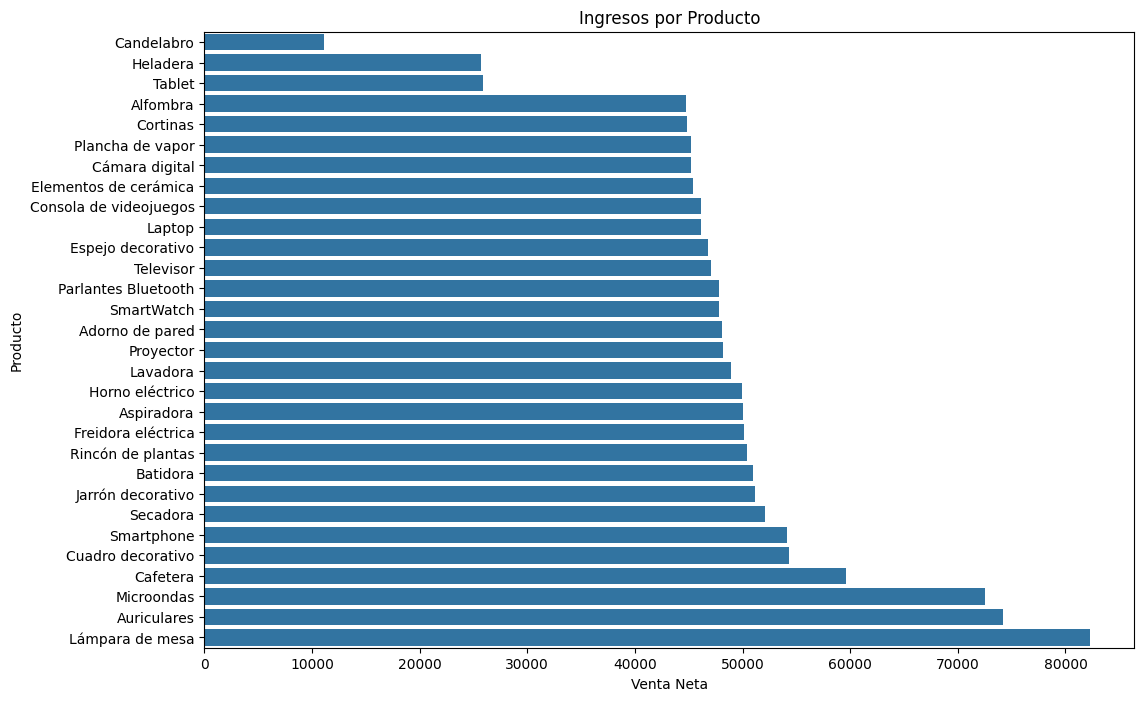

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar datos

ventas_producto_ordenado = ventas_producto.sort_values(
    by="venta_neta",
    ascending=True
)

# Crear gráfico

plt.figure(figsize=(12,8))

sns.barplot(
    data=ventas_producto_ordenado,
    x="venta_neta",
    y="producto"
)

plt.title("Ingresos por Producto")
plt.xlabel("Venta Neta")
plt.ylabel("Producto")

plt.show()

## 2_3 - Agregación de Datos

En esta sección se resumen las ventas por categoría de producto con el objetivo de analizar los ingresos generados por cada segmento comercial.

In [ ]:
# Resumen de ventas por categoría

ventas_categoria = ventas_limpio.groupby(
    "categoria",
    as_index=False
)["venta_neta"].sum()

ventas_categoria

,categoria,venta_neta
0,Decoración,479216.09
1,Electrodomésticos,505299.63
2,Electrónica,482577.80


In [ ]:
# Ordenar categorías por ingresos

ventas_categoria = ventas_categoria.sort_values(
    by="venta_neta",
    ascending=False
)

ventas_categoria

,categoria,venta_neta
1,Electrodomésticos,505299.63
2,Electrónica,482577.80
0,Decoración,479216.09


### Análisis de Ingresos por Categoría

A partir de la agregación realizada se pudo identificar qué categorías generan mayores ingresos dentro del conjunto de ventas analizado.

Este tipo de análisis permite detectar segmentos comerciales con mejor desempeño y puede servir como apoyo para futuras decisiones de negocio y marketing.

## 2_4 - Integración de Datos

En esta sección se combinan los datasets de ventas y marketing con el objetivo de obtener una visión más amplia del comportamiento comercial y el impacto de las campañas de marketing.

In [ ]:
# Integrar datasets

ventas_marketing = pd.merge(
    ventas_limpio,
    marketing_limpio,
    on="producto",
    how="left"
)

ventas_marketing.head(2)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_total,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,349.7,1,RRSS,5.27,2024-04-27,2024-06-04,38 days
1,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,349.7,31,Email,5.28,2024-08-15,2024-09-12,28 days


### Validación de la Integración

Luego de realizar la integración de datasets se validó la cantidad de registros obtenidos.

Se observó que la cantidad de filas aumentó debido a que cada producto puede estar asociado a múltiples campañas y canales de marketing.

In [ ]:
print(f"Registros ventas_limpio: {len(ventas_limpio)}")

print(f"Registros ventas_marketing: {len(ventas_marketing)}")

Registros ventas_limpio: 2998
Registros ventas_marketing: 8994


Se observó que la cantidad de registros aumentó de 2998 a 8994 luego de realizar la integración de datos.

Esto ocurre debido a que cada producto puede estar asociado a múltiples campañas y canales de marketing, generando relaciones de tipo uno a muchos entre ambos datasets.

Como consecuencia, una misma venta puede repetirse varias veces en el resultado del merge.

# Anexo

## Archivos incluidos en la carpeta del proyecto

### Datasets originales

- ventas.csv
- clientes.csv
- marketing.csv

### Notebook Google Colaboratory

- Trabajo Práctico Integrador - Data Analytics.ipynb

## Descripción de archivos

- `ventas.csv`: contiene información de ventas, productos, cantidades y categorías.
- `clientes.csv`: contiene información demográfica y económica de clientes.
- `marketing.csv`: contiene información de campañas de marketing, canales y costos asociados.


# Etapa 3 - Análisis de Datos

## Objetivo

En esta etapa se realizará un análisis estadístico y exploratorio sobre los datos previamente procesados.

Se aplicarán técnicas de estadística descriptiva, análisis exploratorio de datos (EDA), estudio de correlaciones entre variables y consolidación de la información obtenida durante el proyecto.

Los resultados permitirán identificar patrones de comportamiento en las ventas y generar información útil para la toma de decisiones.

## 3.1 Estadística Descriptiva

En esta sección se analizará la variable **venta_neta**, ya que representa el ingreso generado por cada venta y constituye una de las variables más relevantes para el análisis del negocio.

Se calcularán:

### Medidas de tendencia central

- Media
- Mediana
- Moda

### Medidas de dispersión

- Valor mínimo
- Valor máximo
- Rango
- Desviación estándar
- Varianza
- Percentiles

### 3.1.1 Medidas de Tendencia Central


In [ ]:
# Media
media = ventas_limpio["venta_neta"].mean()

# Mediana
mediana = ventas_limpio["venta_neta"].median()

# Moda
moda = ventas_limpio["venta_neta"].mode()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print("Moda:")
print(moda)

Media: 489.36
Mediana: 418.06
Moda:
0     345.33
1    1058.31
Name: venta_neta, dtype: float64


### Interpretación de Resultados

A partir del análisis de la variable **venta_neta** se obtuvieron las siguientes medidas de tendencia central:

- **Media:** 489.36
- **Mediana:** 418.06
- **Moda:** 345.33 y 1058.31

Se observa que la **media** es superior a la **mediana**, lo que sugiere la presencia de ventas de importe elevado que incrementan el promedio general. Esto indica una distribución con cierta asimetría hacia valores altos.

La **mediana** representa el valor central de las ventas, por lo que aproximadamente el 50 % de las operaciones registran una venta neta inferior a **418.06**, mientras que el otro 50 % presenta valores superiores.

En cuanto a la **moda**, se identificaron dos valores (345.33 y 1058.31), lo que indica que la distribución es **bimodal**, es decir, existen dos montos de venta que se repiten con mayor frecuencia dentro del conjunto de datos.

En conjunto, estas medidas permiten concluir que la mayoría de las ventas se concentran en valores cercanos a los **400–500** unidades monetarias, aunque existen operaciones de mayor importe que elevan el promedio general.

### 3.1.2 Medidas de Dispersión

- Valor mínimo
- Valor máximo
- Rango
- Desviación estándar
- Varianza
- Percentiles

In [ ]:
# Valor mínimo
valor_minimo = ventas_limpio["venta_neta"].min()

# Valor máximo
valor_maximo = ventas_limpio["venta_neta"].max()

# Rango
rango = valor_maximo - valor_minimo

# Desviación estándar
desviacion = ventas_limpio["venta_neta"].std()

# Varianza
varianza = ventas_limpio["venta_neta"].var()

# Percentiles
percentiles = ventas_limpio["venta_neta"].quantile([0.25, 0.50, 0.75])

print(f"Valor mínimo: {valor_minimo:.2f}")
print(f"Valor máximo: {valor_maximo:.2f}")
print(f"Rango: {rango:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")
print(f"Varianza: {varianza:.2f}")

print("\nPercentiles")
print(percentiles)

Valor mínimo: 26.30
Valor máximo: 1488.12
Rango: 1461.82
Desviación estándar: 334.28
Varianza: 111744.33

Percentiles
0.25    220.920
0.50    418.065
0.75    709.920
Name: venta_neta, dtype: float64


### Interpretación de Resultados

Los resultados obtenidos fueron:

- **Valor mínimo:** 26.30
- **Valor máximo:** 1488.12
- **Rango:** 1461.82
- **Desviación estándar:** 334.28
- **Varianza:** 111744.33

El amplio rango entre el valor mínimo y el máximo indica que existen diferencias significativas entre las ventas registradas, con operaciones de bajo y alto importe.

La desviación estándar de **334.28** muestra que los valores de la variable **venta_neta** presentan una dispersión considerable respecto de la media, lo que confirma que no todas las ventas tienen un comportamiento uniforme.

Respecto a los percentiles:

- El **25 %** de las ventas presenta ingresos iguales o inferiores a **220.92**.
- El **50 %** de las ventas (mediana) registra ingresos iguales o inferiores a **418.07**.
- El **75 %** de las ventas presenta ingresos iguales o inferiores a **709.92**.

Estos resultados muestran que la mayor parte de las ventas se concentra por debajo de los **710** unidades monetarias, aunque existen operaciones de mayor valor que incrementan la dispersión observada en los datos.

### Resumen de las Medidas Estadísticas

La siguiente tabla resume los principales indicadores estadísticos calculados sobre la variable **venta_neta**.

In [ ]:
# Tabla resumen con las medidas estadísticas

resumen_estadistico = pd.DataFrame({
    "Medida": [
        "Media",
        "Mediana",
        "Moda",
        "Valor mínimo",
        "Valor máximo",
        "Rango",
        "Desviación estándar",
        "Varianza"
    ],
    "Valor": [
        round(media, 2),
        round(mediana, 2),
        ", ".join([f"{valor:.2f}" for valor in moda]),
        round(valor_minimo, 2),
        round(valor_maximo, 2),
        round(rango, 2),
        round(desviacion, 2),
        round(varianza, 2)
    ]
})

display(resumen_estadistico)

,Medida,Valor
0,Media,489.36
1,Mediana,418.06
2,Moda,"345.33, 1058.31"
3,Valor mínimo,26.3
4,Valor máximo,1488.12
5,Rango,1461.82
6,Desviación estándar,334.28
7,Varianza,111744.33


### Conclusión de la Estadística Descriptiva

El análisis estadístico permitió caracterizar el comportamiento general de las ventas mediante medidas de tendencia central y dispersión.

Los resultados muestran que las ventas presentan una variabilidad considerable, con diferencias importantes entre los valores mínimos y máximos registrados. Asimismo, la media superior a la mediana sugiere la presencia de ventas de mayor importe que incrementan el promedio general.

Esta información constituye una base para el análisis exploratorio que se desarrollará en la siguiente sección, donde se utilizarán visualizaciones para identificar patrones, distribuciones y posibles valores atípicos.

## 3.2 Análisis Exploratorio de Datos (EDA)

Una vez completado el proceso de limpieza y preparación de los datos, se realiza un análisis exploratorio mediante visualizaciones.

El objetivo es identificar patrones, tendencias y comportamientos relevantes en las ventas, facilitando la interpretación de los datos y apoyando la toma de decisiones.

Para ello se utilizarán diferentes tipos de gráficos que permitirán analizar la distribución de las ventas, detectar posibles valores atípicos y comparar el desempeño de productos y categorías.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
plt.style.use("default")

### Distribución de las Ventas

Se utiliza un histograma para observar cómo se distribuyen los valores de la variable **venta_neta**.

Este tipo de gráfico permite identificar dónde se concentra la mayor cantidad de ventas y detectar posibles asimetrías en la distribución.

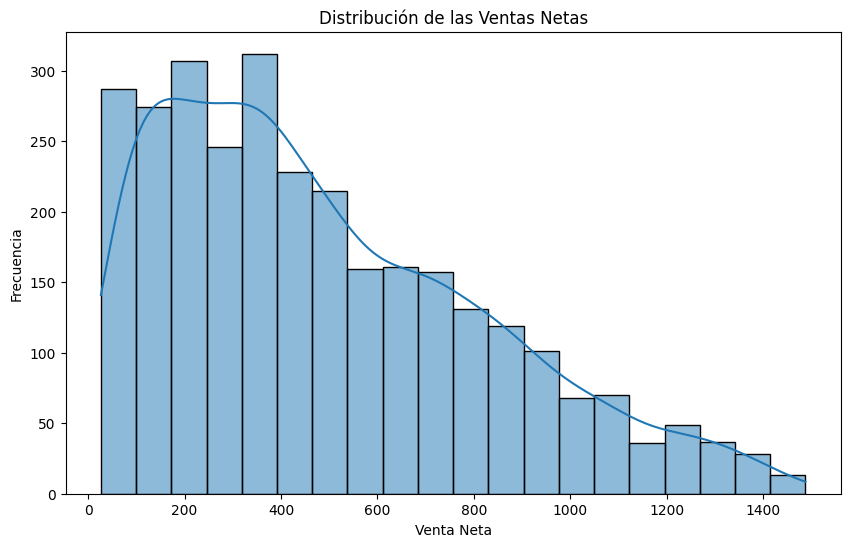

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=ventas_limpio,
    x="venta_neta",
    bins=20,
    kde=True
)

plt.title("Distribución de las Ventas Netas")
plt.xlabel("Venta Neta")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación del Histograma

El histograma muestra la distribución de la variable **venta_neta**, permitiendo observar cómo se distribuyen los ingresos generados por cada venta.

A partir de la visualización se identifican los siguientes aspectos:

- La mayor concentración de ventas se encuentra aproximadamente entre **200 y 500** unidades monetarias.
- A medida que aumenta el valor de la venta, la frecuencia de registros disminuye gradualmente.
- La distribución presenta una **asimetría positiva (sesgo hacia la derecha)**, caracterizada por una cola más extensa hacia los valores altos.
- Se observan algunas ventas de importe elevado, aunque ocurren con una frecuencia considerablemente menor que las ventas de valores intermedios.

Estos resultados son consistentes con el análisis estadístico realizado previamente, donde la **media (489.36)** resultó superior a la **mediana (418.06)**, indicando la presencia de ventas de mayor importe que incrementan el promedio general.

### Identificación de Valores Atípicos

Se utiliza un diagrama de caja (**Boxplot**) para analizar la dispersión de las ventas e identificar posibles valores atípicos.

Este gráfico resume la distribución mediante los cuartiles y facilita la detección de observaciones que se alejan significativamente del comportamiento general de los datos.

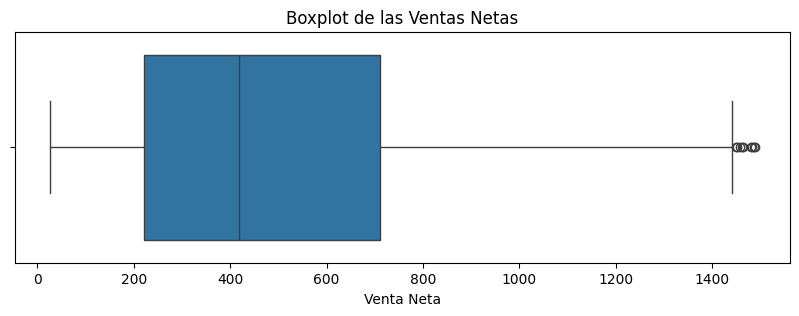

In [ ]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=ventas_limpio["venta_neta"]
)

plt.title("Boxplot de las Ventas Netas")
plt.xlabel("Venta Neta")

plt.show()

### Interpretación del Boxplot

El diagrama de caja permite analizar la distribución de la variable **venta_neta** mediante los cuartiles y facilita la identificación de posibles valores atípicos.

A partir del gráfico se observa que:

- La mediana se ubica aproximadamente en **418**, coincidiendo con el valor obtenido durante el análisis estadístico.
- El 50 % central de las ventas se concentra aproximadamente entre **220** y **710** unidades monetarias, correspondientes al primer y tercer cuartil.
- Se identifican algunos **valores atípicos** en el extremo superior de la distribución, representando ventas con importes significativamente mayores al comportamiento habitual.
- No se observan valores atípicos relevantes en el extremo inferior de la distribución.

La presencia de estos valores elevados explica por qué la **media** resulta superior a la **mediana**, ya que estas observaciones incrementan el promedio general sin representar el comportamiento predominante del conjunto de datos.

En conjunto, el gráfico confirma que la mayoría de las ventas se concentra en un rango relativamente estable, mientras que un pequeño grupo de operaciones presenta ingresos considerablemente superiores.

### Ingresos por Categoría de Producto

Con el objetivo de identificar qué categorías generan mayores ingresos, se analiza la suma de las ventas netas agrupadas por categoría.

Este análisis permite comparar el desempeño comercial de cada categoría de productos y detectar aquellas con mayor contribución a los ingresos totales.

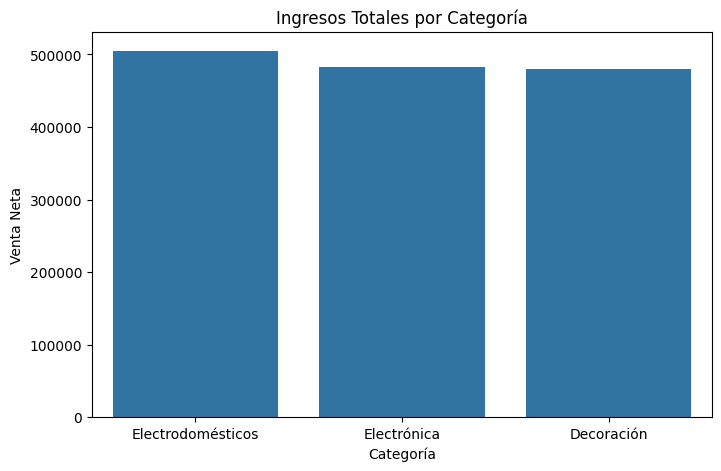

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ventas_categoria,
    x="categoria",
    y="venta_neta"
)

plt.title("Ingresos Totales por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Venta Neta")

plt.show()

### Interpretación de los Ingresos por Categoría

El gráfico de barras muestra el ingreso total generado por cada categoría de productos a partir de la suma de la variable **venta_neta**.

Del análisis del gráfico se desprende que:

- La categoría **Electrodomésticos** presenta el mayor ingreso total dentro del conjunto de datos analizado.
- Las categorías **Electrónica** y **Decoración** registran valores muy similares entre sí, con una diferencia reducida respecto a la categoría líder.
- No se observan diferencias marcadas entre las tres categorías, lo que indica una distribución relativamente equilibrada de los ingresos.

Estos resultados sugieren que las tres categorías contribuyen de manera importante a las ventas totales de la empresa, aunque **Electrodomésticos** presenta un desempeño ligeramente superior.


### Productos con Mayor Ingreso

Con el objetivo de identificar los productos con mejor desempeño comercial, se analizan los ingresos totales generados por cada producto.

Para facilitar la interpretación de los resultados, se presentan únicamente los diez productos con mayores ingresos acumulados.

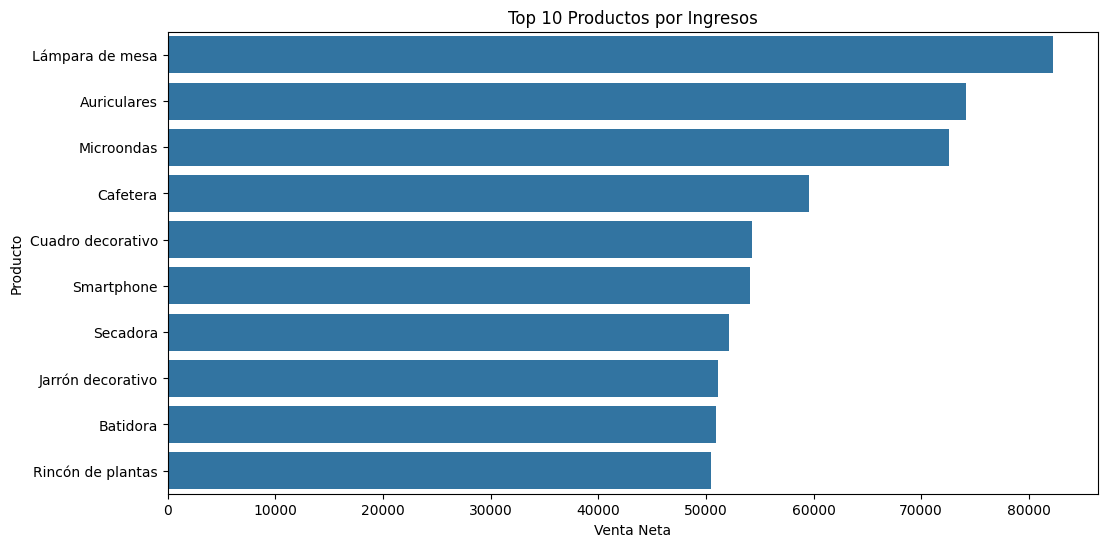

In [ ]:
# 10 productos con mayor ingreso

top10_productos = ventas_producto.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_productos,
    x="venta_neta",
    y="producto"
)

plt.title("Top 10 Productos por Ingresos")
plt.xlabel("Venta Neta")
plt.ylabel("Producto")

plt.show()

### Interpretación de los Productos con Mayor Ingreso

El gráfico presenta los diez productos que generaron el mayor ingreso acumulado durante el período analizado.

A partir de los resultados se observa que:

- **Lámpara de mesa** es el producto con mayor ingreso total, superando los **80.000** en ventas netas.
- **Auriculares** y **Microondas** ocupan el segundo y tercer lugar, respectivamente, manteniendo un desempeño comercial destacado.
- Los productos restantes presentan ingresos relativamente similares, concentrándose aproximadamente entre **50.000** y **60.000** unidades monetarias.
- Se observa una diferencia clara entre el producto con mayor ingreso y el resto del grupo, mientras que las posiciones inferiores del Top 10 muestran valores más homogéneos.

Este análisis permite identificar los productos que realizan el mayor aporte a los ingresos totales de la empresa y constituye una herramienta útil para apoyar decisiones relacionadas con estrategias comerciales, gestión de inventario y planificación de campañas de marketing.

### Evolución Temporal de las Ventas

Para analizar el comportamiento de las ventas a lo largo del tiempo, se agruparon los ingresos por mes utilizando la fecha de venta registrada en el dataset.

Este análisis permite identificar posibles tendencias, variaciones estacionales o cambios en el nivel de ventas durante el período analizado.

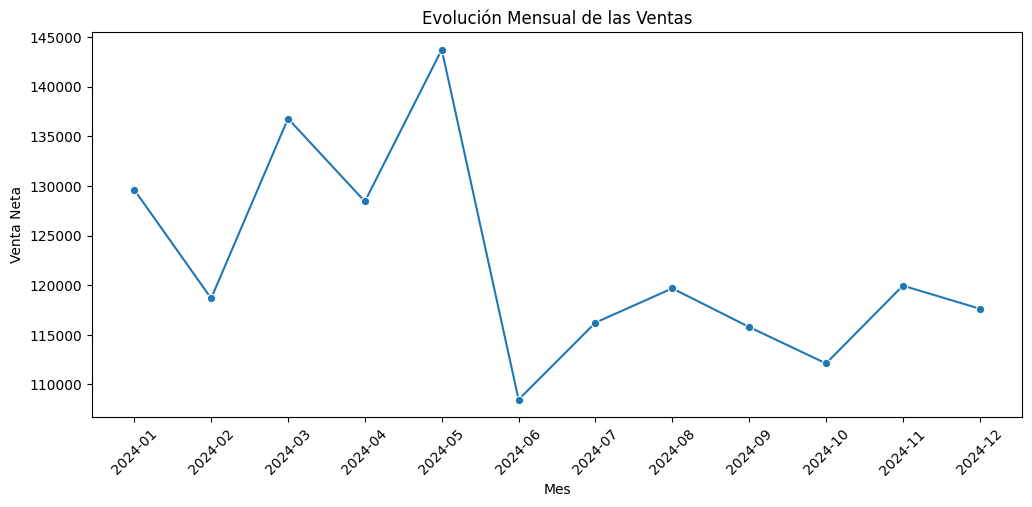

In [ ]:
# Columna con el período mensual
ventas_limpio["mes"] = ventas_limpio["fecha_venta"].dt.to_period("M")

# Agrupar las ventas por mes
ventas_mensuales = (
    ventas_limpio
    .groupby("mes")["venta_neta"]
    .sum()
    .reset_index()
)

# Período a fecha para graficar
ventas_mensuales["mes"] = ventas_mensuales["mes"].astype(str)

# Gráfico
plt.figure(figsize=(12,5))

sns.lineplot(
    data=ventas_mensuales,
    x="mes",
    y="venta_neta",
    marker="o"
)

plt.title("Evolución Mensual de las Ventas")
plt.xlabel("Mes")
plt.ylabel("Venta Neta")
plt.xticks(rotation=45)

plt.show()

### Interpretación de la Evolución Temporal

El gráfico muestra la evolución mensual de los ingresos obtenidos a partir de la variable **venta_neta** durante el año analizado.

Del análisis del gráfico se desprende que:

- Las ventas presentan variaciones a lo largo de los distintos meses del año, sin mantener un comportamiento completamente uniforme.
- El mayor nivel de ingresos se registra en **mayo de 2024**, alcanzando aproximadamente **144.000** unidades monetarias.
- El menor nivel de ventas se observa en **junio de 2024**, inmediatamente después del máximo registrado en mayo.
- Durante el segundo semestre las ventas muestran un comportamiento relativamente estable, con pequeñas fluctuaciones mensuales y sin cambios extremos.

En conjunto, el comportamiento observado evidencia variaciones mensuales normales dentro del período analizado, sin una tendencia sostenida de crecimiento o disminución durante el año.

## 3.3 Correlación entre Variables

La correlación permite medir la intensidad y dirección de la relación existente entre dos variables numéricas.

En esta sección se analizará la relación entre el **precio unitario** y la **cantidad vendida**, utilizando el coeficiente de correlación de Pearson.

Posteriormente, se representará gráficamente dicha relación mediante un gráfico de dispersión para facilitar su interpretación.

In [ ]:
# Correlación entre precio y cantidad

correlacion = ventas_limpio["precio_unitario"].corr(
    ventas_limpio["cantidad"]
)

print(f"Coeficiente de correlación de Pearson: {correlacion:.4f}")

Coeficiente de correlación de Pearson: -0.0024


### Interpretación del Coeficiente de Correlación

El coeficiente de correlación de Pearson obtenido entre las variables **precio_unitario** y **cantidad** fue de **-0.0024**.

Este valor es muy cercano a cero, lo que indica que **no existe una relación lineal significativa** entre ambas variables dentro del conjunto de datos analizado.

En otras palabras, el precio de un producto no parece influir directamente en la cantidad vendida. Se observan ventas de diferentes cantidades tanto para productos de menor precio como para productos de mayor precio.

Este resultado sugiere que otros factores, como la categoría del producto, las campañas de marketing o las preferencias de los clientes, podrían tener una mayor influencia sobre el comportamiento de las ventas.

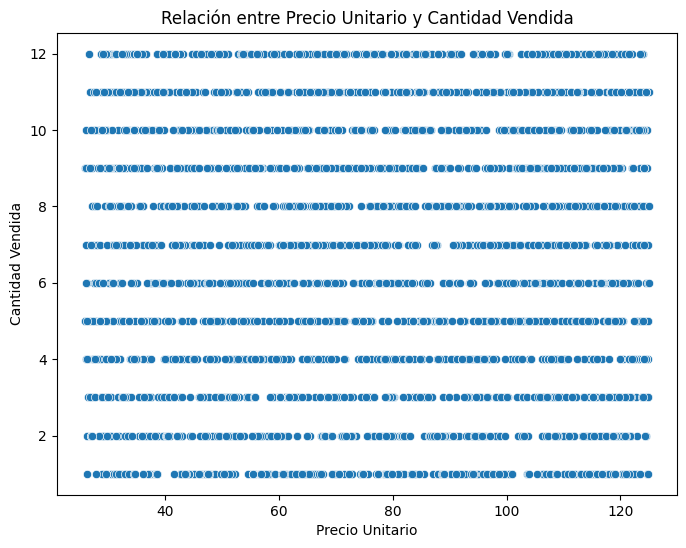

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=ventas_limpio,
    x="precio_unitario",
    y="cantidad"
)

plt.title("Relación entre Precio Unitario y Cantidad Vendida")
plt.xlabel("Precio Unitario")
plt.ylabel("Cantidad Vendida")

plt.show()

### Interpretación del Gráfico de Dispersión

El gráfico de dispersión representa la relación entre el **precio unitario** y la **cantidad vendida** para cada una de las ventas registradas.

Del análisis del gráfico se desprende que:

- Los puntos se encuentran distribuidos de manera dispersa a lo largo del gráfico, sin formar un patrón claramente ascendente o descendente.
- Para prácticamente todos los niveles de precio se registran ventas con diferentes cantidades, lo que indica una alta variabilidad en los datos.
- No se observa una concentración de puntos que sugiera una relación lineal entre ambas variables.

Esta observación coincide con el coeficiente de correlación de Pearson obtenido (**-0.0024**), confirmando que **no existe una relación lineal significativa entre el precio unitario y la cantidad vendida** en el conjunto de datos analizado.

En consecuencia, el precio de los productos no parece ser un factor determinante de la cantidad vendida. Es probable que otros elementos, como la categoría del producto, las campañas de marketing o el comportamiento de los consumidores, tengan una mayor influencia sobre las ventas.

### Conclusión del Análisis de Correlación

El análisis realizado permitió evaluar la relación entre el precio unitario y la cantidad vendida mediante el coeficiente de correlación de Pearson y un gráfico de dispersión.

Los resultados obtenidos indican que no existe una relación lineal significativa entre ambas variables, ya que el coeficiente de correlación es prácticamente nulo y la distribución de los datos no evidencia un patrón definido.

Este hallazgo sugiere que el comportamiento de las ventas depende de múltiples factores y que el precio, por sí solo, no explica las variaciones en la cantidad de productos vendidos.

## 3.4 Consolidación de Datos

En esta sección se consolidan los principales resultados obtenidos durante el análisis con el objetivo de generar un conjunto de datos resumido que facilite la interpretación de la información y pueda utilizarse como base para una presentación o dashboard.

Para ello se recopilan indicadores generales relacionados con las ventas, permitiendo sintetizar los hallazgos más relevantes del proyecto.

In [ ]:
# Resumen consolidado del proyecto

resumen_final = pd.DataFrame({

    "Indicador": [

        "Cantidad de ventas",
        "Ingreso total",
        "Venta promedio",
        "Mediana de ventas",
        "Producto con mayor ingreso",
        "Categoría con mayor ingreso",
        "Cantidad de productos",
        "Cantidad de categorías"

    ],

    "Valor": [

        len(ventas_limpio),

        f"${ventas_limpio['venta_neta'].sum():,.2f}",

        round(media, 2),

        round(mediana, 2),

        ventas_producto.iloc[0]["producto"],

        ventas_categoria.iloc[0]["categoria"],

        ventas_limpio["producto"].nunique(),

        ventas_limpio["categoria"].nunique()

    ]

})

display(resumen_final)

,Indicador,Valor
0,Cantidad de ventas,2998
1,Ingreso total,"$1,467,093.52"
2,Venta promedio,489.36
3,Mediana de ventas,418.06
4,Producto con mayor ingreso,Lámpara de mesa
5,Categoría con mayor ingreso,Electrodomésticos
6,Cantidad de productos,30
7,Cantidad de categorías,3


### Interpretación del Resumen Consolidado

El conjunto de datos consolidado reúne los principales indicadores obtenidos durante el desarrollo del proyecto.

Estos resultados permiten disponer de una visión general del comportamiento de las ventas, destacando aspectos como el ingreso total generado, el promedio de ventas por operación, el producto con mayor desempeño comercial y la categoría con mayor aporte a los ingresos.

La consolidación de esta información facilita la comunicación de resultados y constituye una base adecuada para la elaboración de informes ejecutivos o dashboards de Business Intelligence.

### Preparación del Dataset Consolidado

Como resultado final del análisis se generó un dataset resumido con los principales indicadores obtenidos durante el proyecto.

Este conjunto de datos puede utilizarse como base para futuras visualizaciones, dashboards o informes ejecutivos.

In [ ]:
# Visualización final del dataset consolidado

display(resumen_final)

,Indicador,Valor
0,Cantidad de ventas,2998
1,Ingreso total,"$1,467,093.52"
2,Venta promedio,489.36
3,Mediana de ventas,418.06
4,Producto con mayor ingreso,Lámpara de mesa
5,Categoría con mayor ingreso,Electrodomésticos
6,Cantidad de productos,30
7,Cantidad de categorías,3


In [ ]:
resumen_final.to_csv("resumen_final.csv", index=False)

# Etapa 4 - Visualización de Datos

## Objetivo

En esta etapa se presentan los resultados obtenidos durante el análisis mediante diferentes técnicas de visualización de datos.

Se utilizarán las bibliotecas **Matplotlib**, **Seaborn** y **Plotly** para representar la información de forma clara, facilitando la interpretación de tendencias, comparaciones y relaciones entre variables.

Finalmente, se elaborará un dashboard interactivo y un resumen ejecutivo con los principales hallazgos del proyecto, simulando una presentación ante el equipo de analistas de SynthData.

## 4.1 Visualización con Matplotlib

Las visualizaciones básicas desarrolladas durante la Etapa 3 fueron construidas utilizando Matplotlib.

En esta etapa se profundiza el trabajo mediante visualizaciones estadísticas con Seaborn y un dashboard interactivo desarrollado con Plotly.

## 4.2 Visualización Avanzada con Seaborn

En esta sección se desarrollan visualizaciones avanzadas utilizando estilos, paletas de colores y diferentes tipos de gráficos que permiten mejorar la interpretación de los datos y comunicar los resultados de forma más efectiva.

In [ ]:
# Estilo general de Seaborn

sns.set_theme(
    style="whitegrid",
    palette="viridis"
)

### Distribución de las Ventas Netas

Se representa la distribución de la variable **venta_neta** mediante un histograma acompañado por una curva de densidad (KDE).

Esta visualización permite analizar la concentración de las ventas, identificar la forma de la distribución y observar posibles asimetrías en los datos.

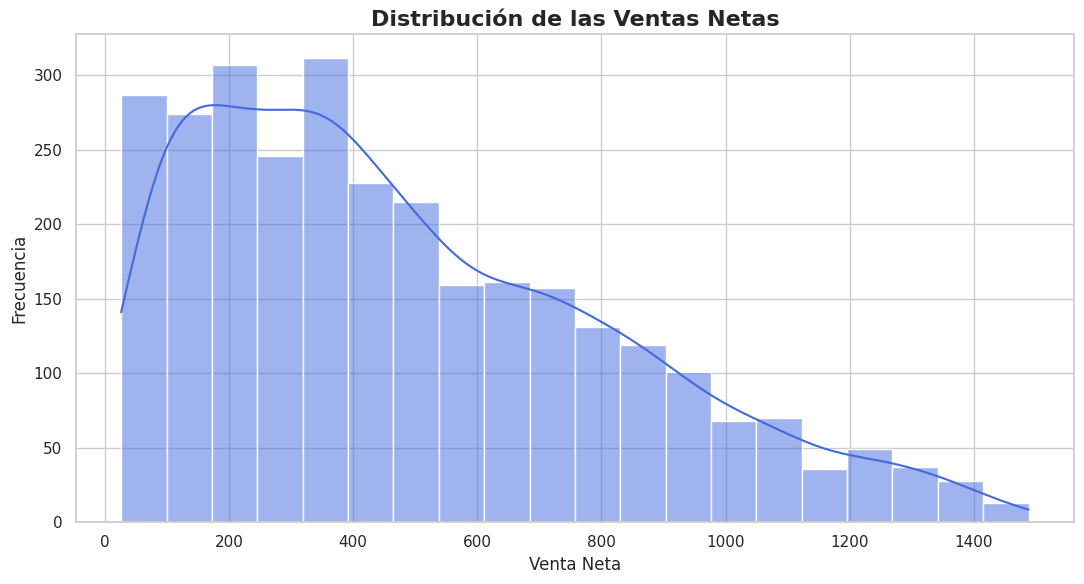

In [ ]:
plt.figure(figsize=(11,6))

sns.histplot(
    data=ventas_limpio,
    x="venta_neta",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title(
    "Distribución de las Ventas Netas",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Venta Neta")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.show()

### Interpretación

La combinación del histograma con la curva de densidad facilita la identificación de la forma de la distribución de las ventas.

La mayor concentración de registros se encuentra en valores intermedios de la variable **venta_neta**, mientras que la cola hacia los valores más altos confirma la presencia de una distribución con asimetría positiva.

La utilización de una curva KDE permite apreciar de manera más clara el comportamiento general de la distribución, complementando el análisis realizado mediante la estadística descriptiva.

### Distribución de las Ventas por Categoría

Se utiliza un diagrama de caja para comparar la distribución de las ventas netas entre las distintas categorías de productos.

Esta visualización permite analizar diferencias en la dispersión, la mediana y la presencia de valores atípicos dentro de cada categoría.

/tmp/ipykernel_14750/3382884206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


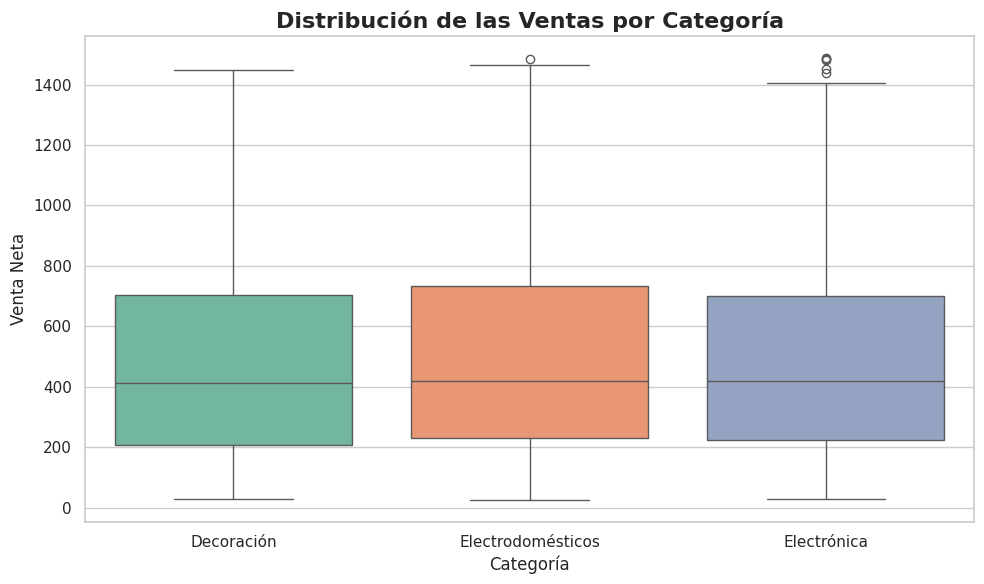

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=ventas_limpio,
    x="categoria",
    y="venta_neta",
    palette="Set2"
)

plt.title(
    "Distribución de las Ventas por Categoría",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Categoría")
plt.ylabel("Venta Neta")

plt.tight_layout()

plt.show()

### Interpretación

El diagrama de caja permite comparar la distribución de las ventas entre las distintas categorías de productos.

A partir de la visualización es posible observar que las tres categorías presentan distribuciones similares, con medianas relativamente cercanas y una dispersión comparable.

Asimismo, se identifican algunos valores atípicos superiores en las distintas categorías, indicando la existencia de ventas de importe elevado que superan el comportamiento habitual del conjunto de datos.

En conjunto, el gráfico confirma que las categorías poseen un comportamiento homogéneo, aunque cada una registra operaciones individuales de alto valor.

### Matriz de Correlación

La matriz de correlación permite visualizar la relación existente entre las principales variables numéricas del conjunto de datos.

Cada celda representa el coeficiente de correlación de Pearson entre dos variables, facilitando la identificación de relaciones positivas, negativas o inexistentes.

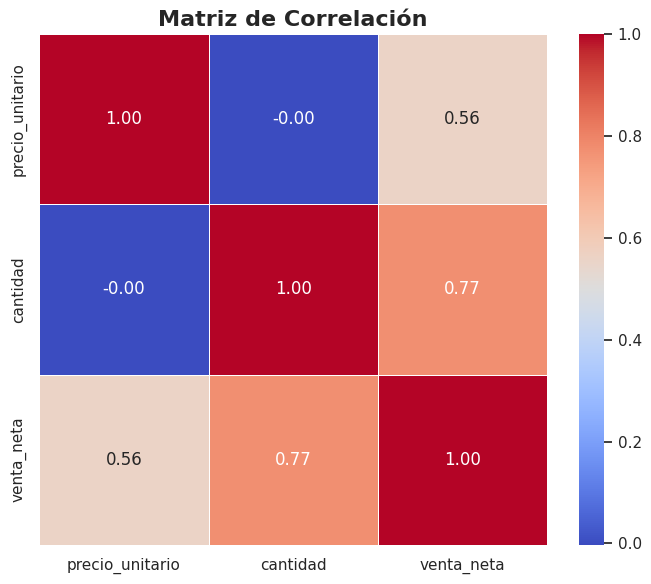

In [ ]:
# Variables numéricas a analizar

correlacion = ventas_limpio[
    [
        "precio_unitario",
        "cantidad",
        "venta_neta"
    ]
].corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Matriz de Correlación",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Interpretación

La matriz de correlación resume la intensidad de la relación lineal entre las principales variables numéricas analizadas: **precio_unitario**, **cantidad** y **venta_neta**.

A partir de los resultados obtenidos se observa que:

- La correlación entre **precio_unitario** y **cantidad** es prácticamente nula (**-0.00**), indicando que no existe una relación lineal significativa entre ambas variables. Esto confirma el análisis realizado previamente mediante el coeficiente de Pearson y el gráfico de dispersión.

- La variable **venta_neta** presenta una **correlación positiva moderada** con el **precio_unitario** (**0.56**), lo que indica que, en general, productos con precios más elevados tienden a generar mayores ingresos, aunque esta relación no es completamente determinante.

- La relación entre **cantidad** y **venta_neta** es **positiva y relativamente fuerte** (**0.77**). Este resultado indica que la cantidad vendida tiene una mayor influencia sobre el ingreso total generado que el precio unitario.

Estos resultados son consistentes con la definición de la variable **venta_neta**, calculada como el producto entre el precio unitario y la cantidad vendida. Sin embargo, la mayor correlación observada con la cantidad sugiere que el volumen de ventas tiene un impacto más importante sobre los ingresos que el precio por sí solo.

En conjunto, la matriz de correlación permite comprender cómo interactúan las principales variables del negocio y constituye una herramienta útil para apoyar futuras decisiones comerciales y análisis más avanzados.

## 4.3 Dashboard Interactivo con Plotly

Como cierre del análisis, se desarrolló un dashboard interactivo utilizando **Plotly**, con el objetivo de integrar en una única vista los principales indicadores y visualizaciones obtenidos durante el proyecto.

El dashboard reúne métricas clave del negocio junto con gráficos interactivos que permiten explorar la evolución de las ventas, el desempeño por categoría, los productos con mayor ingreso y la relación entre el precio unitario y la cantidad vendida.

Esta visualización facilita la comunicación de los resultados y representa una herramienta de apoyo para el análisis y la toma de decisiones.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Top 10 productos por ingreso

top10_plotly = (
    ventas_producto
    .sort_values("venta_neta", ascending=False)
    .head(10)
)

In [ ]:
fig = make_subplots(

    rows=2,
    cols=2,

    subplot_titles=(

        "Ventas Mensuales",

        "Ingresos por Categoría",

        "Precio vs Cantidad",

        "Top 10 Productos"

    )

)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================
# Indicadores principales
# ==========================

ingreso_total = ventas_limpio["venta_neta"].sum()
cantidad_ventas = len(ventas_limpio)
venta_promedio = ventas_limpio["venta_neta"].mean()

# ==========================
# Dashboard
# ==========================

fig = make_subplots(

    rows=3,
    cols=2,

    specs=[
        [{"type":"indicator"},{"type":"indicator"}],
        [{"type":"xy"},{"type":"xy"}],
        [{"type":"xy"},{"type":"xy"}]
    ],

    subplot_titles=(

        "Ingreso Total",
        "Venta Promedio",

        "Ventas Mensuales",
        "Ingresos por Categoría",

        "Precio vs Cantidad",
        "Top 10 Productos"

    ),

    vertical_spacing=0.12,
    horizontal_spacing=0.10

)

# ==========================================
# KPI - Ingreso Total
# ==========================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=ingreso_total,

        number={"prefix":"$","valueformat":",.2f"},

        title={"text":"Ingreso Total"}

    ),

    row=1,
    col=1

)

# ==========================================
# KPI - Venta Promedio
# ==========================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=venta_promedio,

        number={"prefix":"$","valueformat":",.2f"},

        title={"text":"Venta Promedio"}

    ),

    row=1,
    col=2

)

# ==========================================
# Línea
# ==========================================

fig.add_trace(

    go.Scatter(

        x=ventas_mensuales["mes"],
        y=ventas_mensuales["venta_neta"],

        mode="lines+markers",

        name="Ventas"

    ),

    row=2,
    col=1

)

# ==========================================
# Barras
# ==========================================

fig.add_trace(

    go.Bar(

        x=ventas_categoria["categoria"],
        y=ventas_categoria["venta_neta"],

        marker_color="steelblue",

        name="Categorías"

    ),

    row=2,
    col=2

)

# ==========================================
# Scatter
# ==========================================

fig.add_trace(

    go.Scatter(

        x=ventas_limpio["precio_unitario"],
        y=ventas_limpio["cantidad"],

        mode="markers",

        marker=dict(

            color="royalblue",

            size=7,

            opacity=0.55

        ),

        name="Ventas"

    ),

    row=3,
    col=1

)

# ==========================================
# Top Productos
# ==========================================

fig.add_trace(

    go.Bar(

        x=top10_plotly["venta_neta"],
        y=top10_plotly["producto"],

        orientation="h",

        marker=dict(

            color=top10_plotly["venta_neta"],
            colorscale="Blues"

        ),

        name="Productos"

    ),

    row=3,
    col=2

)

# ==========================================
# Diseño general
# ==========================================

fig.update_layout(

    title={

        "text":"SynthData Sales Dashboard",
        "x":0.5

    },

    template="plotly_white",

    height=1100,

    showlegend=False,

    margin=dict(

        l=40,
        r=40,
        t=80,
        b=40

    )

)

fig.show()

### Interpretación

El dashboard integra en una única vista los principales resultados obtenidos durante el desarrollo del proyecto.

Los indicadores superiores presentan una síntesis del desempeño general de las ventas, mientras que las visualizaciones permiten analizar la evolución temporal, comparar el rendimiento de las categorías, identificar los productos con mayor ingreso y evaluar la relación entre el precio unitario y la cantidad vendida.

La interactividad proporcionada por Plotly facilita la exploración de los datos mediante herramientas como zoom, desplazamiento y visualización de información detallada al posicionar el cursor sobre cada elemento del gráfico.

Este tipo de dashboard constituye una herramienta de apoyo para el análisis ejecutivo, permitiendo comunicar los resultados de manera clara y dinámica.

# 4.4 Presentación Final

## Executive Summary

### Objetivo del Proyecto

El objetivo de este proyecto fue desarrollar un proceso completo de análisis de datos, abarcando las etapas de recopilación, limpieza, transformación, análisis estadístico y visualización de la información.

A partir de los conjuntos de datos proporcionados, se aplicaron diferentes herramientas y técnicas de Python para preparar los datos y obtener información que facilitara la comprensión del comportamiento de las ventas.

---

## Metodología

El desarrollo del proyecto se llevó a cabo en cuatro etapas principales:

- Carga y exploración inicial de los conjuntos de datos.
- Limpieza y transformación de la información para garantizar su calidad.
- Análisis estadístico y exploratorio mediante técnicas descriptivas y visualizaciones.
- Construcción de un dashboard interactivo para resumir los principales indicadores del negocio.

Este flujo de trabajo permitió pasar de datos sin procesar a información organizada y lista para apoyar la toma de decisiones.

---

## Principales Insights

Durante el análisis se identificaron los siguientes resultados:

- El conjunto de datos de ventas contenía registros duplicados y algunos valores nulos que fueron eliminados durante el proceso de limpieza.
- La categoría **Electrodomésticos** fue la que generó el mayor ingreso total durante el período analizado.
- **Lámpara de mesa** fue el producto con mayor ingreso acumulado.
- La evolución mensual mostró variaciones en el nivel de ventas, alcanzando su mayor valor durante el mes de mayo.
- El análisis de correlación indicó que no existe una relación lineal significativa entre el precio unitario y la cantidad vendida.
- La cantidad de productos vendidos presentó una mayor influencia sobre el ingreso total que el precio unitario.

---

## Insights

A partir de los resultados obtenidos se identifican algunas oportunidades de análisis:

- Los ingresos dependen principalmente del volumen de ventas y no exclusivamente del precio de los productos.
- Los productos con mejor desempeño podrían utilizarse como referencia para futuras campañas comerciales.
- La estabilidad observada entre categorías sugiere un portafolio relativamente equilibrado, sin una dependencia excesiva de una única línea de productos.

---

## Recomendaciones

Como resultado del análisis realizado, se proponen las siguientes acciones:

- Continuar monitoreando mensualmente el desempeño de las ventas mediante dashboards interactivos.
- Analizar en mayor profundidad el comportamiento de los productos con mayor ingreso para identificar factores de éxito.
- Incorporar nuevas variables, como descuentos, promociones o estacionalidad, para ampliar futuros análisis.
- Mantener procesos periódicos de validación y limpieza de datos antes de realizar nuevos estudios.

---

## Conclusión

El desarrollo del proyecto permitió recorrer todas las etapas de un proceso de Data Analytics, desde la preparación de los datos hasta la generación de visualizaciones e indicadores para apoyar el análisis del negocio. Los resultados obtenidos demuestran la importancia de la calidad de los datos y del análisis exploratorio como base para la obtención de información confiable. Finalmente, el dashboard interactivo resume los principales indicadores del proyecto y facilita la comunicación de los resultados de forma clara y dinámica.